# Candidate Test 2022 Analysis Part 1

This exercise focuses on the candidate tests from two television networks: DR and TV2. Data from both tests have been given on a scale of five responses (-2, -1, 0, 1, 2).

---

There are 6 datasets included in this exercise:

- `alldata.xlsx`: Contains responses from both TV stations.
- `drdata.xlsx`: Contains responses from DR.
- `drq.xlsx`: Contains questions from DR.
- `tv2data.xlsx`: Contains responses from TV2.
- `tv2q.xlsx`: Contains questions from TV2.
- `electeddata.xlsx`: Contains responses from both TV stations for candidates who were elected to the parliament. Note that 9 members are missing; 7 of them didn't take any of the tests. Additionally, some notable figures like Mette F. and Lars Løkke did not participate in any of the tests.

---

It's entirely up to you how you approach this data, but at a *minimum*, your analysis should include:
- Age of the candidates grouped by parties.
- An overview of the most "confident" candidates, i.e., those with the highest proportion of "strongly agree" or "strongly disagree" responses.
- Differences in responses between candidates, both inter-party and intra-party, along with an explanation of which parties have the most internal disagreements.
- Classification models to predict candidates' party affiliations. Investigate if there are any candidates who seem to be in the "wrong" party based on their political landscape positions. You must use the following  algorithms: **Decision Tree**, **Random Forest** and **Gradient Boosted Tree**, i.e. a total of 3 models are to be trained.

---

The following parties are represented:

| Party letter | Party name | Party name (English) | Political position |
| :-: | :-: | :-: | :-: |
| A | Socialdemokratiet | Social Democrats | Centre-left |
| V | Venstre | Danish Liberal Party | Centre-right |
| M | Moderaterne | Moderates | Centre-right |
| F | Socialistisk Folkeparti | Socialist People's Party | Left-wing |
| D | Danmarksdemokraterne | Denmark Democrats | Right-wing |
| I | Liberal Alliance | Liberal Alliance | Right-wing |
| C | Konservative | Conservative People's Party | Right-wing |
| Æ | Enhedslisten | Red-Green Alliance | Far-left |
| B | Radikale Venstre | Social Liberal Party | Centre-left |
| D | Nye Borgerlige | New Right | Far-right |
| Z | Alternativet | The Alternative | Centre-left |
| O | Dansk Folkeparti | Danish People's Party | Far-right |
| G | Frie Grønne | Free Greens | Centre-left |
| K | Kristendemokraterne | Christian Democrats | Centre-right |

Below you can see the results and the colors chosen to represent the parties. Use these colors in your analysis above.

![Alt text](image-1.png)


Others have undertaken similar analyses. You can draw inspiration from the following (use Google tranlsate if your Danish is rusty):

- [Analysis of where individual candidates stand relative to each other and their parties](https://v2022.dumdata.dk/)
- [Candidate Test 2022 – A deep dive into the data](https://kwedel.github.io/kandidattest2022/)
- [The Political Landscape 2019](https://kwedel.github.io/kandidattest2019/)



In [60]:
import pandas as pd

alldata = pd.read_excel('alldata.xlsx')
drdata = pd.read_excel('drdata.xlsx')
drq = pd.read_excel('drq.xlsx')
tv2data = pd.read_excel('tv2data.xlsx')
tv2q = pd.read_excel('tv2q.xlsx')
electeddata = pd.read_excel('electeddata.xlsx')

# Analysis

### Age of Candidates Grouped by Party

In [61]:
# data's not clean... some ages are 0.
relevant_cols = alldata[['parti', 'alder']]
relevant_cols = relevant_cols[relevant_cols['alder'] != 0]

In [62]:
parties = sorted(relevant_cols['parti'].unique())
analysis = relevant_cols.groupby(['parti']).describe().round(1)

display(analysis)

alder                          \
                                            count  mean   std   min   25%   
parti                                                                       
Alternativet                                 65.0  47.4  13.6  21.0  39.0   
Danmarksdemokraterne                         37.0  51.2  10.3  24.0  45.0   
Dansk Folkeparti                             49.0  45.5  12.2  20.0  39.0   
Det Konservative Folkeparti                  94.0  44.7  11.9  20.0  37.0   
Enhedslisten                                 71.0  42.2  15.2  19.0  31.0   
Frie Grønne, Danmarks Nye Venstrefløjsparti  26.0  34.8  10.8  20.0  27.5   
Kristendemokraterne                          41.0  50.2  13.4  21.0  43.0   
Liberal Alliance                             68.0  38.0  13.7  18.0  26.0   
Løsgænger                                     3.0  48.0   9.2  40.0  43.0   
Moderaterne                                  42.0  44.3  13.8  19.0  35.2   
Nye Borgerlige                               50.0  48.5  12.2  20.0  42.2   
Radikale Venstre                             67.0  45.0  12.4  21.0  36.0   
Socialdemokratiet                            85.0  45.4  11.6  20.0  37.0   
Socialistisk Folkeparti                      69.0  41.5  13.5  20.0  29.0   
Venstre                                      84.0  46.7  12.2  18.0  38.0   

                                                               
                                              50%   75%   max  
parti                                                          
Alternativet                                 48.0  58.0  79.0  
Danmarksdemokraterne                         53.0  59.0  69.0  
Dansk Folkeparti                             47.0  54.0  75.0  
Det Konservative Folkeparti                  48.0  53.0  66.0  
Enhedslisten                                 41.0  53.5  74.0  
Frie Grønne, Danmarks Nye Venstrefløjsparti  33.0  37.5  62.0  
Kristendemokraterne                          50.0  61.0  73.0  
Liberal Alliance                             37.0  46.0  72.0  
Løsgænger                                    46.0  52.0  58.0  
Moderaterne                                  45.0  52.8  78.0  
Nye Borgerlige                               49.5  56.5  70.0  
Radikale Venstre                             45.0  54.0  76.0  
Socialdemokratiet                            45.0  53.0  78.0  
Socialistisk Folkeparti                      42.0  52.0  68.0  
Venstre                                      48.0  57.0  69.0

### Confident Candidates

In [63]:
# use all members again, since age not relevant
num_questions = alldata.drop(['navn', 'parti', 'storkreds', 'alder'], axis='columns').shape[1]


In [64]:
def get_confidence_pct(entry):
    confident_responses = entry.isin([-2, 2]).sum()
    return confident_responses / num_questions

In [65]:
alldata['confidence'] = alldata.apply(get_confidence_pct, axis=1)

candidates = alldata[['navn', 'confidence']].sort_values(by = 'confidence', ascending = False)
candidates.head()

,navn,confidence
505,Sarah Nørris,1.000000
88,Søren Vanting,1.000000
559,Kim Andkjær Doberck,0.897959
44,Mohamed Abdikarim,0.877551
152,Rashid Ali,0.877551


In [66]:
alldata = alldata.drop(['confidence'], axis='columns')

### Inter-Party Correlation

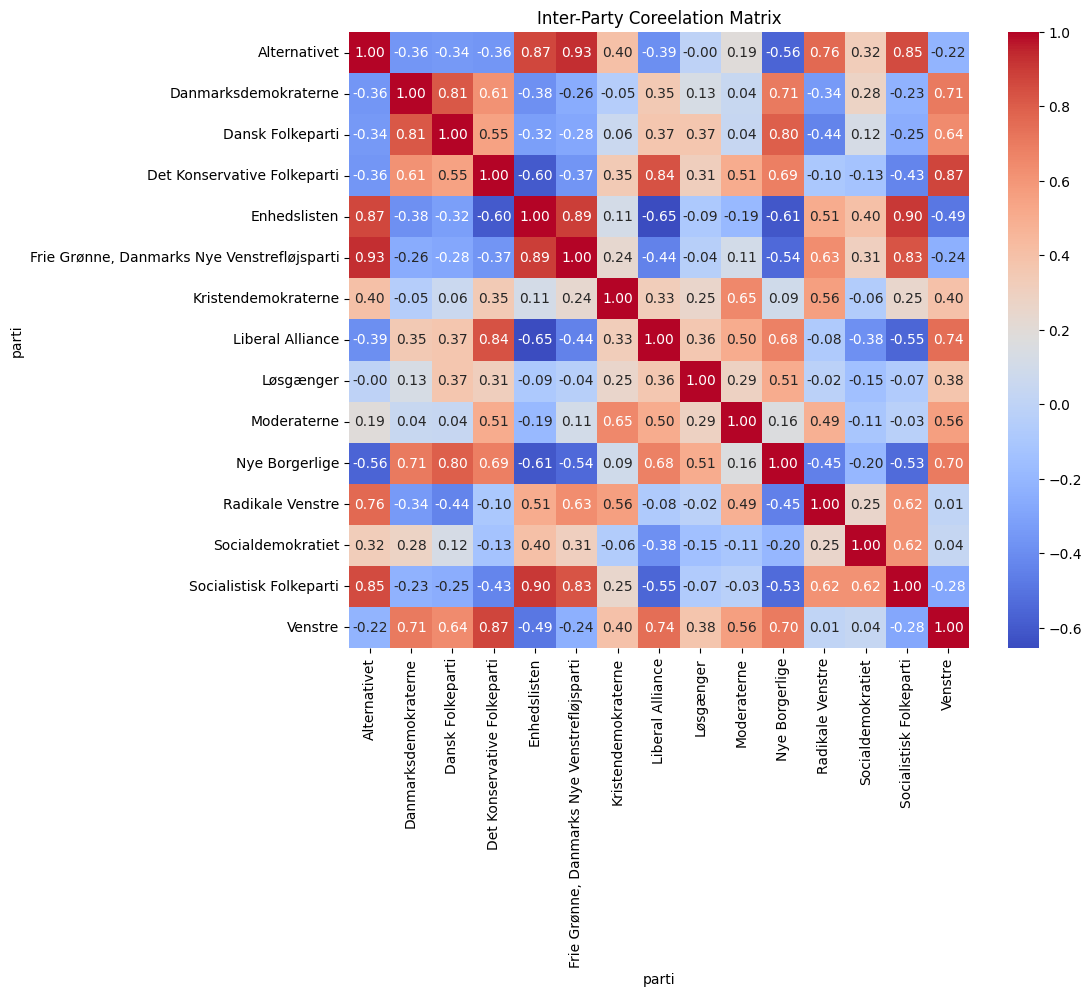

In [67]:
import seaborn as sns
import matplotlib.pyplot as plt

relevant_cols = alldata.drop(['navn', 'storkreds', 'alder'], axis='columns')
avg_response_per_party = relevant_cols.groupby('parti').mean()

scale = avg_response_per_party.T.corr() # gets parties, not questions
plt.figure(figsize=(10, 8))
sns.heatmap(scale, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Inter-Party Coreelation Matrix")
plt.show()

### Intra-Party Correlation

In [68]:
import numpy as np
from sklearn.metrics.pairwise import cosine_similarity

def calc_similarity(data, party_name):
    party_data = data[data['parti'] == party_name]
    party_data = party_data.drop(['navn', 'storkreds', 'alder', 'parti'], axis='columns')

    similarity_matrix = cosine_similarity(party_data)
    avg_similarity = (similarity_matrix[np.triu_indices(similarity_matrix.shape[0], k=1)]).mean()

    return avg_similarity

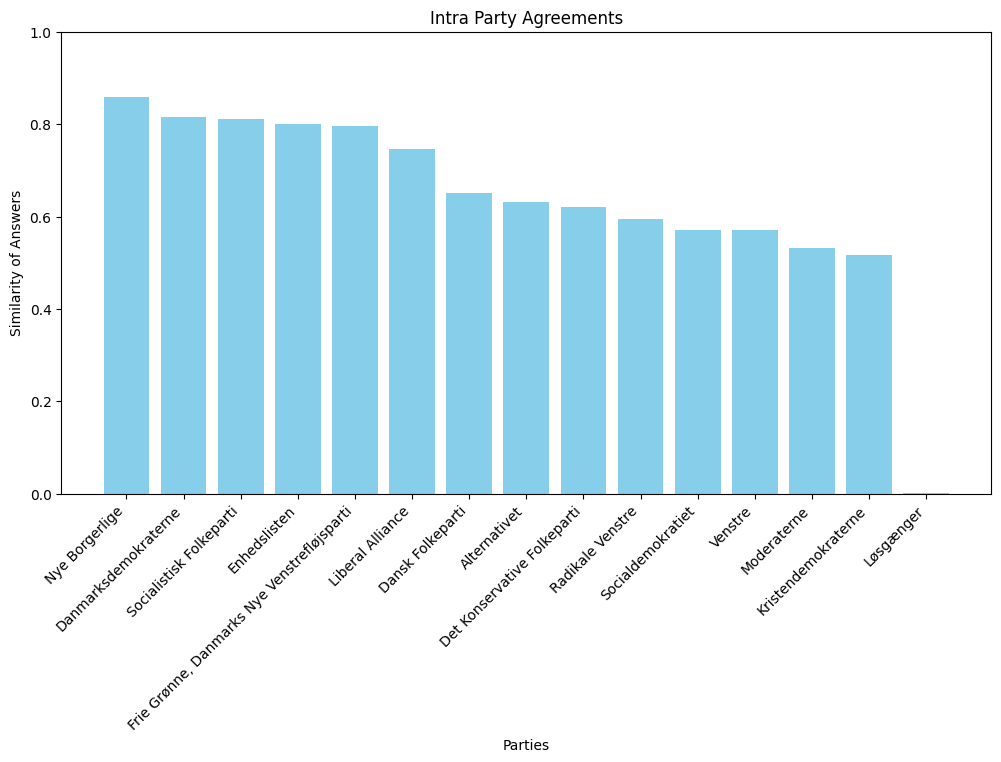

In [69]:
parties = sorted(alldata['parti'].unique())
party_list = {}

for party in parties:
    similarity = calc_similarity(alldata, party)
    party_list.update({party: similarity})

party_list = dict(sorted(party_list.items(), key=lambda item: item[1], reverse=True))

# Creating the bar chart
plt.figure(figsize=(12, 6))
plt.bar(party_list.keys(), party_list.values(), color='skyblue')
plt.xlabel('Parties')
plt.xticks(rotation=45, ha='right')
plt.ylabel('Similarity of Answers')
plt.title('Intra Party Agreements')
plt.ylim(0, 1)
plt.show()

Løsgænger has the most disagreements, which makes sense (if you consider them a party) because they represent the members of parliament that have left their affiliated party, which may be scattered across political alignments.

### Models

##### Decision Tree

In [103]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.model_selection import train_test_split

# clean
data_filtered = alldata.drop(['navn'], axis = 'columns')
data_filtered = data_filtered.loc[(alldata['alder'] != 0) & (alldata['parti'] != 'Løsgænger')]
data_filtered = data_filtered.dropna()

# get label
labels = data_filtered['parti']
data_filtered = data_filtered.drop(['parti'], axis = 'columns')

# encode storkreds
data_encoded = pd.get_dummies(data_filtered, columns=['storkreds'], drop_first=True)
X_train, X_test, y_train, y_test = train_test_split(data_encoded, labels, test_size=0.2, random_state=42)

In [ ]:
from sklearn.metrics import accuracy_score

tree_model = DecisionTreeClassifier(random_state=42)
tree_model.fit(X_train, y_train)

y_pred = tree_model.predict(X_test)

print(accuracy_score(y_test, y_pred))

0.7294117647058823


##### Random Forest

In [105]:
forest_model = RandomForestClassifier(random_state=42)
forest_model.fit(X_train, y_train)

y_pred = forest_model.predict(X_test)

print(accuracy_score(y_test, y_pred))


0.9411764705882353


##### Gradient Boosted

In [106]:
gradient_model = GradientBoostingClassifier(random_state=42)
gradient_model.fit(X_train, y_train)

y_pred = gradient_model.predict(X_test)

print(accuracy_score(y_test, y_pred))

0.9
